# Predicting location of hyperbolas Object Detection and fitting

This Notebook is based on the interaction with the YOLO Model for Object Detection. And how to try to fit hyperbolas

- Chapter 1: Load Yolo Model
- Chapter 2: Predicting Locations of Hyperbolas with YOLO Model
- Chapter 3: Extracting Bounding Boxes
- Chapter 4: Edge Detection



### Chapter 1: Load Yolo Model

following code shows loading a Yolo Model directly threw the **ultralytics** Library.

In [2]:
#import libraries
import numpy as np
from ultralytics import YOLO

#Setting Working directory
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

#Import the config file so that only the Filename needs to be changed in the _read_segy function
from config import *




In [3]:
#Load trained Model for Object Detection
model = YOLO(YOLO_MODEL_OD_DIR)


### Chapter 2: Predicting Locations of Hyperbolas with YOLO Model

for prediction Data is needed. The idea is to take a sgy file and use the same code as when created the images for training but now it is used to create random test pictures out of the file. Second Option is that we take the test set out of Roboflow. for the first option a function is created.

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import segyio
import random

def create_random_test_images(df, file, test_inline_random:bool = False, test_crossline_random:bool = False, test_timeslice_random:bool = False,
                        number_random_inlines:int = 1, number_random_crosslines:int = 1, number_random_timeslices:int = 1
                        ):
    
    outdir = TEST_PIC_OD_H_DIR
    filename = df["filename"].iloc[0]

    bin_header = dict(file.bin)
    bin_header_dict = dict(bin_header)
    n_samples = int(bin_header_dict[segyio.BinField.Samples])

    inlines = sorted(df["inline"].unique())
    crosslines = sorted(df["crossline"].unique())

    il_map = {v: i for i, v in enumerate(inlines)}
    cl_map = {v: i for i, v in enumerate(crosslines)}

    if test_inline_random:
        inlines = random.sample(inlines, min(number_random_inlines, len(inlines)))
        for inline_nr in inlines:
            sub = df[df["inline"] == inline_nr].sort_values("crossline")
            img = np.vstack(sub["Amplitude"].values).T
            out_path = os.path.join(outdir, f"{filename}_inline_{inline_nr}.png")
            plt.imsave(out_path, img, cmap="grey")
        
        print(f"saved {len(inlines)} images to {outdir}")
        
    if test_crossline_random:
        crosslines = random.sample(crosslines, min(number_random_crosslines, len(crosslines)))
        for crossline_nr in crosslines:
            sub = df[df["crossline"] == crossline_nr].sort_values("inline")
            img = np.vstack(sub["Amplitude"].values).T
            out_path = os.path.join(outdir, f"{filename}_crossline_{crossline_nr}.png")
            plt.imsave(out_path, img, cmap="grey")
        
        print(f"saved {len(crosslines)} images to {outdir}")
        
    if test_timeslice_random:
        rand_timeslices = random.sample(range(n_samples), min(number_random_timeslices, n_samples))
        for sample_index in rand_timeslices:
            mat = np.full((len(inlines), len(crosslines)), np.nan)

            for _,row in df.iterrows():
                i = il_map[row["inline"]]
                j = cl_map[row["crossline"]]
                mat[i, j] = row["Amplitude"][sample_index]
        
            img = np.nan_to_num(mat)
            out_path=os.path.join(outdir, f"{filename}_timeslice_{sample_index}.png")
            plt.imsave(out_path, img, cmap="grey")
        
        print(f"saved {len(rand_timeslices)} images to {outdir}")






next step is to load the File

In [ ]:
from Pipeline.Datatoolkit import DatatoolKit

dk = DatatoolKit(TEST_FILE_DIR , "EG-3D QUER001.SGY")
dk2 = DatatoolKit(TEST_FILE_DIR, "UG3DQUERUNTERZUG.SGY")
file = dk.LoadSGY()
file2 = dk.LoadSGY()
df_file1 = dk.create_df(file)
df_file2 = dk2.create_df


lets create random test pictures

In [14]:
create_random_test_images(df=df_file1, 
              file=file,
              test_inline_random=True,
              number_random_inlines=6)

saved 6 images to c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Object_Detection_Hyperbola\pictures


In [15]:
create_random_test_images(df=df_file2, 
              file=file,
              test_inline_random=True,
              number_random_inlines=6)

saved 6 images to c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Object_Detection_Hyperbola\pictures


Next step is to make prediction of images which are in one directory.

In [16]:
model.predict(TEST_PIC_OD_H_DIR,save =True, conf=0.1)


image 1/12 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Object_Detection_Hyperbola\pictures\EG-3D QUER001.SGY_inline_13.png: 128x640 2 hyperbolas, 89.8ms
image 2/12 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Object_Detection_Hyperbola\pictures\EG-3D QUER001.SGY_inline_15.png: 128x640 (no detections), 28.1ms
image 3/12 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Object_Detection_Hyperbola\pictures\EG-3D QUER001.SGY_inline_21.png: 128x640 1 hyperbola, 24.2ms
image 4/12 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Object_Detection_Hyperbola\pictures\EG-3D QUER001.SGY_inline_23.png: 128x640 (no detections), 23.3ms
image 5/12 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Object_Detection_Hyperbola\pictures\EG-3D QUER001.SGY_inline_4.png: 128x640 4 hyperbolas, 28.0ms
image 6/12 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Object_Detection_Hyperbola\pictures\EG-3D QUER001.SGY_inline_63.png: 128x640 3 hyperbolas, 23.1ms
image 7/12 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Object_Detectio

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'hyperbola'}
 obb: None
 orig_img: array([[[ 97,  97,  97],
         [ 97,  97,  97],
         [ 97,  97,  97],
         ...,
         [ 94,  94,  94],
         [ 92,  92,  92],
         [ 89,  89,  89]],
 
        [[ 87,  87,  87],
         [ 87,  87,  87],
         [ 88,  88,  88],
         ...,
         [ 92,  92,  92],
         [ 89,  89,  89],
         [ 88,  88,  88]],
 
        [[ 88,  88,  88],
         [ 88,  88,  88],
         [ 88,  88,  88],
         ...,
         [ 91,  91,  91],
         [ 91,  91,  91],
         [ 89,  89,  89]],
 
        ...,
 
        [[146, 146, 146],
         [141, 141, 141],
         [121, 121, 121],
         ...,
         [146, 146, 146],
         [144, 144, 144],
         [149, 149, 149]],
 
        [[152, 152, 152],
         [146, 146, 146],
         [141, 141, 141],
         ...,
         [146, 

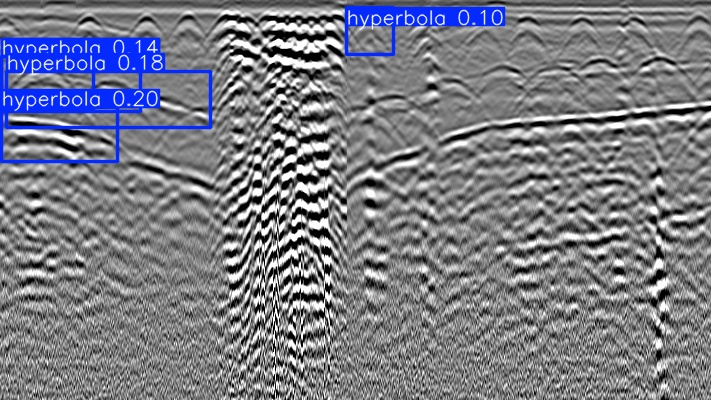

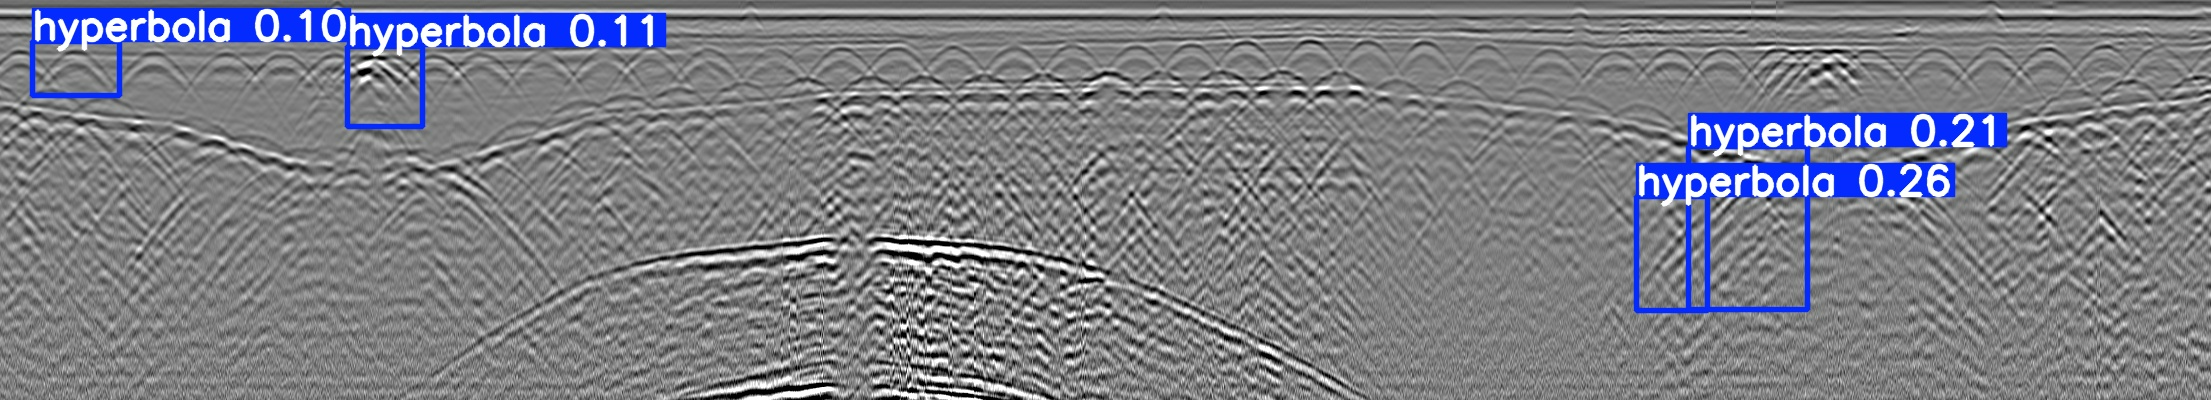

It shows that with the Object Detection Model there are not much hyperbolas are detected even with a low confidence setting.This is the case for both files. and there are pretty wrong. Must have a look at in validation

## Chapter 3: Extracting Bounding Boxes

for further processing the Bounding boxes of predictions are needed. With Yolo it is fairyl simple to extract those bounding boxes. For that a function is implemented that does exactly that. The idea is that it extracts all bounding bounding boxes from all images predictions are made on. This function makes predictions and extracting bounding boxes simultaniously. And since in practice not two measures are combined in one analysis the focus lies on one File and that file is **UG3DQUERUNTERZUG.SGY**

In [20]:
def extract_bboxes(prediction_folder)-> list:
    results = model.predict(source=prediction_folder, save = True, conf=0.1)
    all_boxes = {}

    for result in results:
        img_name = os.path.basename(result.path)
        if result.boxes is not None:
            boxes = result.boxes.xyxy.cpu().numpy()
            all_boxes[img_name] = boxes# Bounding boxes in (x1, y1, x2, y2) format
        else:
            all_boxes[img_name] = np.empty((0,4))       
        
    return all_boxes

In [21]:
boxes = extract_bboxes(TEST_PIC_OD_H_DIR)


image 1/6 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Object_Detection_Hyperbola\pictures\UG3DQUERUNTERZUG.SGY_inline_12.png: 128x640 1 hyperbola, 31.9ms
image 2/6 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Object_Detection_Hyperbola\pictures\UG3DQUERUNTERZUG.SGY_inline_32.png: 128x640 (no detections), 33.0ms
image 3/6 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Object_Detection_Hyperbola\pictures\UG3DQUERUNTERZUG.SGY_inline_39.png: 128x640 1 hyperbola, 26.7ms
image 4/6 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Object_Detection_Hyperbola\pictures\UG3DQUERUNTERZUG.SGY_inline_41.png: 128x640 (no detections), 24.5ms
image 5/6 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Object_Detection_Hyperbola\pictures\UG3DQUERUNTERZUG.SGY_inline_48.png: 128x640 1 hyperbola, 23.9ms
image 6/6 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Object_Detection_Hyperbola\pictures\UG3DQUERUNTERZUG.SGY_inline_59.png: 128x640 4 hyperbolas, 28.6ms
Speed: 1.0ms preprocess, 28.1ms inference, 0.8ms postprocess

In [22]:
print(boxes)

{'UG3DQUERUNTERZUG.SGY_inline_12.png': array([[     342.79,      54.863,      392.72,      125.62]], dtype=float32), 'UG3DQUERUNTERZUG.SGY_inline_32.png': array([], shape=(0, 4), dtype=float32), 'UG3DQUERUNTERZUG.SGY_inline_39.png': array([[          0,      44.144,      50.958,      97.537]], dtype=float32), 'UG3DQUERUNTERZUG.SGY_inline_41.png': array([], shape=(0, 4), dtype=float32), 'UG3DQUERUNTERZUG.SGY_inline_48.png': array([[       1860,      149.05,      1948.9,      282.85]], dtype=float32), 'UG3DQUERUNTERZUG.SGY_inline_59.png': array([[     310.94,      47.664,      384.89,      118.97],
       [     374.53,      47.617,      441.99,      123.66],
       [          0,      33.227,      52.186,      96.616],
       [     558.99,       42.93,      685.59,      98.006]], dtype=float32)}


Next step is to translate the Data from the Bounding boxes into the Data given by the Data. Therefore a function is created that exactly does that

In [24]:
#translate bboxes coordinates to sgy date

def bbox_to_data(df, bbox:dict,sample_interval=None):

    results = {}

    for img_name, box_list in bbox.items():
        if "_inline_" not in img_name:
            continue
        inline_nr = int(img_name.split("_inline_")[1].split(".")[0])
        results[img_name] = []

        for bbox in box_list:
            x1,y1,x2,y2 = map(int, bbox)

            sub = df[(df["inline"] == inline_nr) & (df["crossline"].between(x1,x2))]
            sub = sub.sort_values("crossline")
            if sub.empty:
                continue

            amp_slice = np.vstack([
                np.array(row["Amplitude"])[y1:y2] for _, row in sub.iterrows()
            ]).T

            
            if sample_interval is not None:
                time_start_us = y1 * sample_interval
                time_end_us = y2 * sample_interval
            else:
                time_start_us = time_end_us = None

            results[img_name].append({
                "bbox": bbox,
                "inline": inline_nr,
                "crossline_min": int(sub["crossline"].min()),
                "crossline_max": int(sub["crossline"].max()),
                "sample_start": y1,
                "sample_end": y2,
                "time_start_us": time_start_us,
                "time_end_us": time_end_us,
                "amplitudes": amp_slice
            })

    return results


In [25]:
results = bbox_to_data(df_file2, boxes)

In [26]:
results

{'UG3DQUERUNTERZUG.SGY_inline_12.png': [{'bbox': array([     342.79,      54.863,      392.72,      125.62], dtype=float32),
   'inline': 12,
   'crossline_min': 342,
   'crossline_max': 392,
   'sample_start': 54,
   'sample_end': 125,
   'time_start_us': None,
   'time_end_us': None,
   'amplitudes': array([[13789, 14820, 15840, ..., 16216, 17392, 18063],
          [ 7458,  8728, 10544, ...,  8312, 10016, 11606],
          [-1222,  -161,  1688, ..., -3163, -1831,    22],
          ...,
          [ 2103,  2785,  2874, ...,  6364,  4306,  2427],
          [ 3910,  4130,  3818, ..., 11570, 10266,  8790],
          [ 4207,  3850,  3137, ..., 13726, 13726, 13108]], shape=(71, 51), dtype=int16)}],
 'UG3DQUERUNTERZUG.SGY_inline_32.png': [],
 'UG3DQUERUNTERZUG.SGY_inline_39.png': [{'bbox': array([          0,      44.144,      50.958,      97.537], dtype=float32),
   'inline': 39,
   'crossline_min': 1,
   'crossline_max': 50,
   'sample_start': 44,
   'sample_end': 97,
   'time_start_us': N

### Chapter 4: Edge Detections

Here the idea is to make an edge detection on the Bounding Boxes which are translatet to the Data. For the Edge Detection die canny edge Algorithm is used which is a common Algorithm for Edge Detection.

In [27]:
import cv2
import numpy as np

sigma = 1
low = 0.3
high = 0.7

edge_results = {}

for img_name , entries in results.items():
    edge_results[img_name] = []

    for e in entries:
        amp = e["amplitudes"].astype(float)

        #normalize
        img = (amp - np.min(amp)) / (np.max(amp) - np.min(amp) + 1e-9)
        img =  (img * 255).astype(np.uint8)

        blurred = cv2.GaussianBlur(img, (3,3), sigma)
        edges = cv2.Canny(blurred, int(low *255), int(high*255))

        e_new = e.copy()
        e_new["edges"] = edges
        edge_results[img_name].append(e_new)


Next step is to inspect the Edge detections and looks at them if there are also many other structures detectet or there only the edges from the Hyperbolas left hich is the Goal with the Edge Detection. for that the following code saves the edge detection results in the folder **edgedetections**

In [29]:
import matplotlib.pyplot as plt

outputdir = EDGE_DETECT_DIR



for img_name, entries in edge_results.items():
    base = os.path.splitext(img_name)[0]
    for idx, e in enumerate(entries):
        if "edges" not in e:
            continue

        edges = e["edges"]
        if edges.dtype != np.uint8:
            edges = np.clip(edges, 0, 255).astype(np.uint8)

        out_path = os.path.join(outputdir, f"{base}_bbox{idx+1}_edges.png")
        cv2.imwrite(out_path, edges)
        

Inspection of a couple of results of the filtering of hyperbolas with egedetections shows that this Workflow is not really satisfing at probably would need a lot more coding and time. Therefore the idea is to switch to a model with Instance Segmentation as Identifier of Hyperbolas.

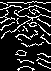
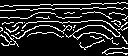
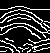

